In [1]:
# --- Cell 1: Imports ---
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import config
from model import UNet3D  # same as in train_validate_motor_only.py

In [2]:
# --- Cell 2: Setup device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [3]:
# --- Cell 3: Dataset and preprocessing (copied from train_validate_motor_only.py) ---
from torch.utils.data import Dataset
from scipy.ndimage import zoom, gaussian_filter
from skimage.transform import resize
from PIL import Image

BASE_DATA_DIR = config.BASE_DATA_DIR

RAW_VOXEL_SIZE_ANGSTROM = np.array([13.68, 109.44, 109.44])  # (Z, Y, X)
SIGMA_CHOICES = [2, 3, 4, 5, 6]

def percentile_normalize(volume, low=0.5, high=99.5):
    vmin, vmax = np.percentile(volume, [low, high])
    volume = np.clip(volume, vmin, vmax)
    volume = 2.0 * (volume - vmin) / (vmax - vmin + 1e-8) - 1.0
    return volume.astype(np.float32)

def downsample_xy(volume, factor=8):
    zoom_factors = (1.0, 1.0 / factor, 1.0 / factor)
    return zoom(volume, zoom_factors, order=1)

def generate_gaussian_heatmap(coords_np, shape, sigma=2):
    """Same as training: fixed sigma=2."""
    heatmap = np.zeros(shape, dtype=np.float32)
    if coords_np.size > 0:
        Z, Y, X = shape
        for z, y, x in coords_np:
            if 0 <= z < Z and 0 <= y < Y and 0 <= x < X:
                heatmap[int(z), int(y), int(x)] = 1.0
    heatmap = gaussian_filter(heatmap, sigma=sigma)
    return np.clip(heatmap.astype(np.float32), 0, 1.0)

class TomoDataset(Dataset):
    def __init__(self, tomo_ids, labels_df, augment=False):
        self.tomo_ids = list(tomo_ids)
        self.labels_df = labels_df
        self.augment = augment

    def __len__(self):
        return len(self.tomo_ids)

    def __getitem__(self, idx):
        tomo_id = self.tomo_ids[idx]
        tomo_dir = os.path.join(BASE_DATA_DIR, tomo_id)

        slice_paths = sorted(Path(tomo_dir).glob("slice_*.jpg"))
        vol_slices = [np.array(Image.open(p).convert("L"), dtype=np.float32) for p in slice_paths]
        volume = np.stack(vol_slices, axis=0)

        # normalize
        volume = percentile_normalize(volume)

        # store shape
        orig_z, orig_y, orig_x = volume.shape

        # downsample XY
        volume = downsample_xy(volume, factor=8)
        ds_z, ds_y, ds_x = volume.shape

        # pad/crop Z
        if ds_z >= 128:
            z_start = (ds_z - 128) // 2
            volume = volume[z_start:z_start+128, :, :]
            z_offset = -z_start
        else:
            pad_before = (128 - ds_z) // 2
            pad_after = 128 - ds_z - pad_before
            volume = np.pad(volume, ((pad_before, pad_after), (0, 0), (0, 0)), mode="constant")
            z_offset = pad_before
        ds_z = 128

        # resize XY
        volume = resize(volume, (ds_z, 128, 128), order=1, preserve_range=True, anti_aliasing=True).astype(np.float32)

        # GT coords
        df_tomo = self.labels_df[self.labels_df["tomo_id"] == tomo_id]
        coords = df_tomo[["Motor axis 0", "Motor axis 1", "Motor axis 2"]].values if not df_tomo.empty else np.empty((0, 3), dtype=int)
        coords = coords[~np.any(coords == -1, axis=1)] if coords.size > 0 else coords
        coords = coords.astype(np.float32)

        if coords.size > 0:
            coords[:, 1] /= 8.0
            coords[:, 2] /= 8.0
            coords[:, 0] += z_offset
            coords[:, 1] *= (128.0 / ds_y)
            coords[:, 2] *= (128.0 / ds_x)
            coords[:, 0] = np.clip(coords[:, 0], 0, ds_z - 1)
            coords[:, 1:] = np.clip(coords[:, 1:], 0, 127)
        coords = np.rint(coords).astype(int)

        eff_voxel_size = np.array([
            RAW_VOXEL_SIZE_ANGSTROM[0],
            RAW_VOXEL_SIZE_ANGSTROM[1] * (orig_y / 128.0),
            RAW_VOXEL_SIZE_ANGSTROM[2] * (orig_x / 128.0),
        ])

        heatmap = generate_gaussian_heatmap(coords, volume.shape, sigma=2)

        volume = torch.from_numpy(volume).unsqueeze(0)
        heatmap = torch.from_numpy(heatmap).unsqueeze(0)

        return volume, heatmap, tomo_id, coords, eff_voxel_size

In [4]:
# --- Cell 4: Load labels and split validation tomos ---
labels_df = pd.read_csv(config.LABELS_CSV)
val_ids = [p.name for p in sorted(Path(BASE_DATA_DIR).glob("tomo_*"))]

motor_val_ids, no_motor_val_ids = [], []
for tomo_id in val_ids:
    df_tomo = labels_df[labels_df["tomo_id"] == tomo_id]
    coords = df_tomo[["Motor axis 0", "Motor axis 1", "Motor axis 2"]].values if not df_tomo.empty else np.empty((0, 3), dtype=int)
    coords = coords[~np.any(coords == -1, axis=1)] if coords.size > 0 else coords
    if len(coords) > 0:
        motor_val_ids.append(tomo_id)
    else:
        no_motor_val_ids.append(tomo_id)

print(f"Validation tomos with motors: {len(motor_val_ids)}")
print(f"Validation tomos without motors: {len(no_motor_val_ids)}")

motor_sample = motor_val_ids[:5]
no_motor_sample = no_motor_val_ids[:5]
print("Motor sample IDs:", motor_sample)
print("No-motor sample IDs:", no_motor_sample)

Validation tomos with motors: 362
Validation tomos without motors: 286
Motor sample IDs: ['tomo_00e047', 'tomo_00e463', 'tomo_01a877', 'tomo_02862f', 'tomo_033ebe']
No-motor sample IDs: ['tomo_003acc', 'tomo_0308c5', 'tomo_0333fa', 'tomo_040b80', 'tomo_049310']


In [5]:
# --- Cell 5: Load trained model ---
ckpt_path = "/data/horse/ws/rabo074f-team_project/BYU2/checkpoints_motors_only/latest.pt"
model = UNet3D(in_channels=1, out_channels=1, dropout=0.3).to(device)
model.load_state_dict(torch.load(ckpt_path, map_location=device))
model.eval()
print(f"Loaded model from {ckpt_path}")

Loaded model from /data/horse/ws/rabo074f-team_project/BYU2/checkpoints_motors_only/latest.pt


In [6]:
# --- Cell 6: Visualization + F2 helpers (merged) ---
import torch
from scipy.ndimage import maximum_filter
from scipy.spatial import cKDTree

DIST_THRESHOLD_ANGSTROM = 1000.0  # match training

def pick_z_index(gt_heatmap, fallback_depth):
    if gt_heatmap is None or gt_heatmap.max() <= 0.0:
        return fallback_depth // 2
    return int(np.argmax(gt_heatmap.sum(axis=(1, 2))))

def robust_limits(img, lo=1, hi=99):
    vmin, vmax = np.percentile(img, [lo, hi])
    if vmin == vmax:
        vmax = vmin + 1e-6
    return float(vmin), float(vmax)

def extract_peaks(prob_map, threshold=0.3, min_distance=3):
    mask = prob_map > threshold
    local_max = (maximum_filter(prob_map, size=min_distance) == prob_map) & mask
    return np.argwhere(local_max)

def _flatten_coords(points):
    arr = np.asarray(points)
    if arr.size == 0:
        return np.empty((0, 3), dtype=np.float32)
    if arr.ndim == 1:
        arr = arr.reshape(1, -1)
    elif arr.ndim > 2:
        arr = arr.reshape(-1, arr.shape[-1])
    return arr.astype(np.float32)

def compute_f2_score_peaks(pred_map, gt_points, voxel_size, threshold=0.3, min_distance=3):
    pred_pts = extract_peaks(pred_map, threshold, min_distance)
    gt_points = _flatten_coords(gt_points)
    pred_pts  = _flatten_coords(pred_pts)
    if pred_pts.shape[0] == 0 and gt_points.shape[0] == 0: return 1.0
    if pred_pts.shape[0] == 0 or gt_points.shape[0] == 0: return 0.0
    gt_ang, pr_ang = gt_points * voxel_size, pred_pts * voxel_size
    kdt = cKDTree(gt_ang)
    matches = kdt.query_ball_point(pr_ang, r=DIST_THRESHOLD_ANGSTROM)
    tp = sum(1 for m in matches if len(m) > 0)
    fp, fn = len(pr_ang)-tp, len(gt_ang)-tp
    precision = tp / (tp+fp+1e-8)
    recall = tp / (tp+fn+1e-8)
    beta=2
    return (1+beta**2)*precision*recall / (beta**2*precision+recall+1e-8)

def show_triplet_at_z(tomo_id, volume, gt_heatmap, pred_heatmap, z_mode="gt"):
    if z_mode=="mip":
        vis_inp, vis_gt, vis_pred = volume.max(0), gt_heatmap.max(0), pred_heatmap.max(0)
        z_info="MIP"
    else:
        z = pick_z_index(gt_heatmap, volume.shape[0]) if z_mode=="gt" else volume.shape[0]//2
        vis_inp, vis_gt, vis_pred = volume[z], gt_heatmap[z], pred_heatmap[z]
        z_info=f"z={z}"
    vmin_inp,vmax_inp=robust_limits(vis_inp)
    vmin_gt,vmax_gt=robust_limits(vis_gt,0,100)
    vmin_pr,vmax_pr=robust_limits(vis_pred,0,100)
    fig,axs=plt.subplots(1,3,figsize=(12,3.2))
    axs[0].imshow(vis_inp,cmap="gray",vmin=vmin_inp,vmax=vmax_inp); axs[0].set_title(f"{tomo_id} - Input ({z_info})"); axs[0].axis("off")
    axs[1].imshow(vis_gt,cmap="inferno",vmin=vmin_gt,vmax=vmax_gt); axs[1].set_title("GT Heatmap"); axs[1].axis("off")
    axs[2].imshow(vis_pred,cmap="inferno",vmin=vmin_pr,vmax=vmax_pr); axs[2].set_title("Prediction Heatmap"); axs[2].axis("off")
    plt.tight_layout(); plt.show()

def debug_and_eval_tomos(tomo_ids, labels_df, model, device,
                         batch_size=1, z_mode="gt",
                         peak_thr=0.3, peak_min_dist=3):
    from torch.utils.data import DataLoader
    ds = TomoDataset(tomo_ids, labels_df, augment=False)
    dl = DataLoader(ds,batch_size=batch_size,shuffle=False,num_workers=0)
    model.eval()
    rows=[]
    with torch.no_grad():
        for volume_t, gt_heatmap_t, tomo_id, coords, vox_size_t in dl:
            tid = tomo_id[0]
            volume = volume_t[0,0].cpu().numpy()
            gt_map = gt_heatmap_t[0,0].cpu().numpy()
            logits = model(volume_t.to(device))
            pred = torch.sigmoid(logits)[0,0].cpu().numpy()
            gt_pts = coords[0].numpy() if hasattr(coords[0],"numpy") else np.asarray(coords[0])
            vox = vox_size_t[0].numpy() if hasattr(vox_size_t[0],"numpy") else np.asarray(vox_size_t[0])
            f2 = compute_f2_score_peaks(pred, gt_pts, vox, threshold=peak_thr, min_distance=peak_min_dist)
            num_gt = 0 if gt_pts.size==0 else gt_pts.shape[0]
            num_pred = extract_peaks(pred, threshold=peak_thr, min_distance=peak_min_dist).shape[0]
            print(f"{tid}: F2={f2:.4f} | GT pts={num_gt} | pred peaks={num_pred} | GT max={gt_map.max():.3f} | Pred max={pred.max():.3f}")
            show_triplet_at_z(tid, volume, gt_map, pred, z_mode=z_mode)
            rows.append({"tomo_id":tid,"F2":f2,"GT_points":num_gt,"Pred_peaks":num_pred,"GT_max":float(gt_map.max()),"Pred_max":float(pred.max())})
    return pd.DataFrame(rows)

Motor validation tomos:
tomo_00e047: F2=0.0000 | GT pts=1 | pred peaks=0 | GT max=0.008 | Pred max=0.101


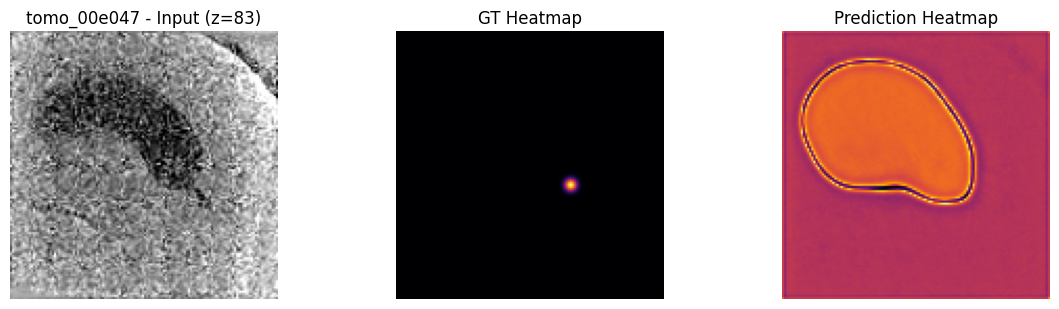

tomo_00e463: F2=0.0000 | GT pts=6 | pred peaks=0 | GT max=0.010 | Pred max=0.105


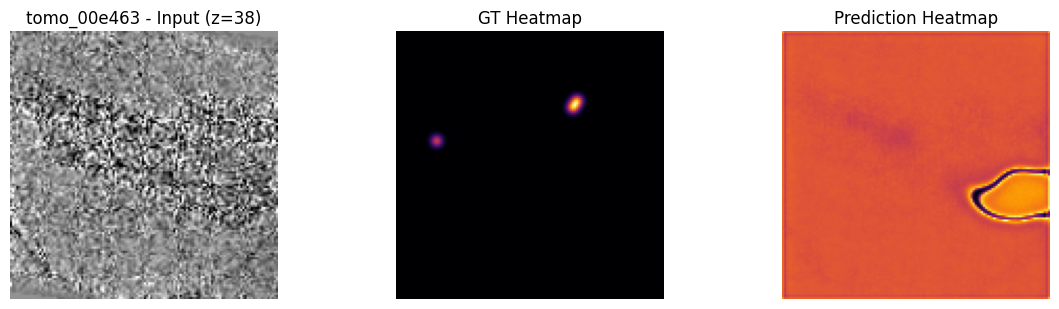

tomo_01a877: F2=0.0000 | GT pts=1 | pred peaks=0 | GT max=0.008 | Pred max=0.105


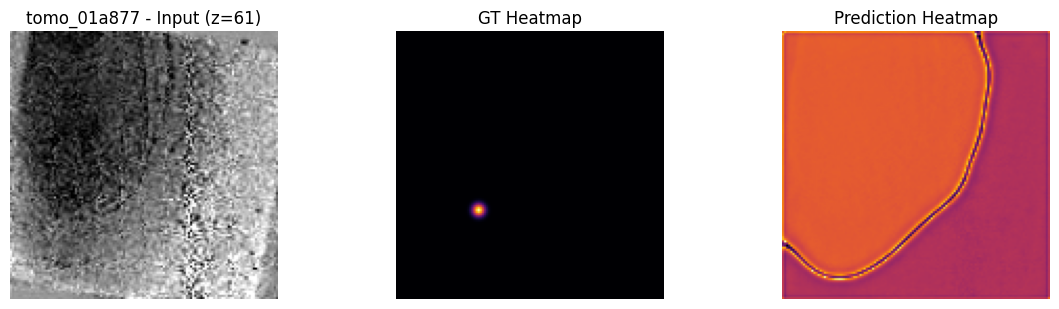

tomo_02862f: F2=0.0000 | GT pts=1 | pred peaks=0 | GT max=0.008 | Pred max=0.096


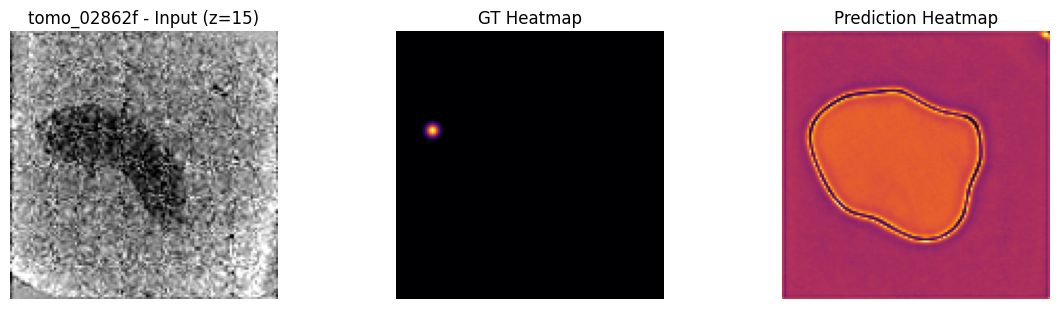

tomo_033ebe: F2=0.0000 | GT pts=1 | pred peaks=0 | GT max=0.008 | Pred max=0.103


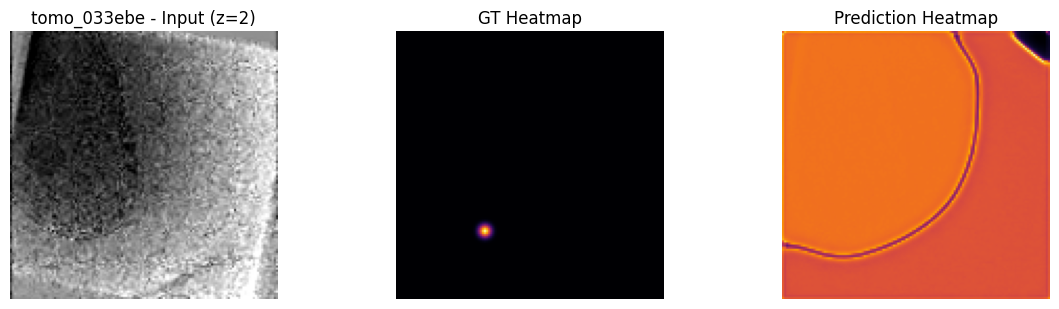


Summary (motor sample):


,tomo_id,F2,GT_points,Pred_peaks,GT_max,Pred_max
0,tomo_00e047,0.0,1,0,0.007937,0.100803
1,tomo_00e463,0.0,6,0,0.010433,0.104947
2,tomo_01a877,0.0,1,0,0.007937,0.105295
3,tomo_02862f,0.0,1,0,0.007937,0.096206
4,tomo_033ebe,0.0,1,0,0.008286,0.103218


Mean F2 (motor sample): 0.0


In [7]:
# --- Cell 7: Run debug ---
print("Motor validation tomos:")
motor_df = debug_and_eval_tomos(motor_sample, labels_df, model, device, peak_thr=0.3)

print("\nSummary (motor sample):")
from IPython.display import display
display(motor_df)
print("Mean F2 (motor sample):", float(motor_df["F2"].mean()))

In [7]:
# --- Cell 8: Robust summary for NO-MOTOR tomos ---

import os, gc
import numpy as np
import torch
import pandas as pd
from pathlib import Path
from PIL import Image

# use the same globals you already defined
BASE_DATA_DIR = config.BASE_DATA_DIR
RAW_VOXEL_SIZE_ANGSTROM = np.array([13.68, 109.44, 109.44], dtype=np.float32)  # (Z, Y, X)

# be gentle with CPU threads (helps prevent kernel crashes)
try:
    torch.set_num_threads(1)
    torch.set_num_interop_threads(1)
except Exception:
    pass

def _percentile_normalize_small(vol_small: np.ndarray, low=0.5, high=99.5):
    vmin, vmax = np.percentile(vol_small, [low, high])
    vol_small = np.clip(vol_small, vmin, vmax)
    vol_small = 2.0 * (vol_small - vmin) / (vmax - vmin + 1e-8) - 1.0
    return vol_small.astype(np.float32)

def load_processed_tomo_min_mem(tomo_id: str,
                                target_xy: int = 128,
                                target_z: int = 128):
    """
    Minimal-memory loader for inference ONLY:
      • reads only the center `target_z` slices (pads if fewer),
      • resizes each slice to `target_xy` while reading (so memory stays tiny),
      • normalizes on the small volume,
      • transforms GT coords consistently with your original logic,
      • returns [1,1,Z,Y,X], coords (Nx3), eff voxel size.
    """
    tomo_dir = os.path.join(BASE_DATA_DIR, tomo_id)
    slice_paths = sorted(Path(tomo_dir).glob("slice_*.jpg"))
    if not slice_paths:
        raise RuntimeError(f"No slices found in {tomo_dir}")

    # original XY from first slice
    with Image.open(slice_paths[0]) as im0:
        orig_x, orig_y = im0.size  # PIL gives (width=x, height=y)

    Z_total = len(slice_paths)

    # pick center chunk of Z
    if Z_total >= target_z:
        z_start = (Z_total - target_z) // 2
        use_paths = slice_paths[z_start:z_start + target_z]
        z_offset = -z_start
        pad_before = pad_after = 0
    else:
        use_paths = slice_paths
        z_offset = (target_z - Z_total) // 2
        pad_before = z_offset
        pad_after = target_z - Z_total - pad_before

    # read + downscale on the fly
    vol_small = np.empty((len(use_paths), target_xy, target_xy), dtype=np.float32)
    for i, p in enumerate(use_paths):
        with Image.open(p) as im:
            im = im.convert("L").resize((target_xy, target_xy), Image.BILINEAR)
            vol_small[i] = np.asarray(im, dtype=np.float32)

    # pad along Z if needed
    if pad_before or pad_after:
        vol_small = np.pad(vol_small, ((pad_before, pad_after), (0, 0), (0, 0)), mode="constant")

    # normalize after shrinking (cheap and stable)
    vol_small = _percentile_normalize_small(vol_small, 0.5, 99.5)

    # GT coords from labels (will be empty for true no-motor tomos)
    df_tomo = labels_df[labels_df["tomo_id"] == tomo_id]
    coords = (df_tomo[["Motor axis 0", "Motor axis 1", "Motor axis 2"]].values
              if not df_tomo.empty else np.empty((0, 3), dtype=int))
    if coords.size > 0:
        coords = coords[~np.any(coords == -1, axis=1)].astype(np.float32)
        # Z shift due to center crop/pad
        coords[:, 0] += z_offset
        # Direct XY resize from original to target_xy (matches your net effect)
        coords[:, 1] *= (target_xy / float(orig_y))
        coords[:, 2] *= (target_xy / float(orig_x))
        # clip + round
        coords[:, 0] = np.clip(coords[:, 0], 0, target_z - 1)
        coords[:, 1] = np.clip(coords[:, 1], 0, target_xy - 1)
        coords[:, 2] = np.clip(coords[:, 2], 0, target_xy - 1)
        coords = np.rint(coords).astype(int)
    else:
        coords = np.empty((0, 3), dtype=int)

    # effective voxel size (same formula as your training code)
    eff_voxel_size = np.array([
        RAW_VOXEL_SIZE_ANGSTROM[0],
        RAW_VOXEL_SIZE_ANGSTROM[1] * (orig_y / target_xy),
        RAW_VOXEL_SIZE_ANGSTROM[2] * (orig_x / target_xy),
    ], dtype=np.float32)

    volume_t = torch.from_numpy(vol_small).unsqueeze(0).unsqueeze(0)  # [1,1,Z,Y,X]
    return volume_t, coords, eff_voxel_size

def summarize_no_motor_tomos(tomo_ids,
                             labels_df,
                             model,
                             device,
                             peak_thrs=(0.1, 0.3, 0.5),
                             min_distance=3):
    """
    Summary-only evaluation for NO-MOTOR tomos:
      • uses the minimal-memory loader above,
      • no plotting,
      • same extract_peaks + compute_f2_score_peaks as in Cell 6.
    """
    rows = []
    model.eval()
    with torch.no_grad():
        for tid in tomo_ids:
            vol_t, coords, vox = load_processed_tomo_min_mem(tid)  # coords empty when no motors
            pred = torch.sigmoid(model(vol_t.to(device)))[0, 0].cpu().numpy()

            gt_empty = np.empty((0, 3), dtype=np.float32)  # explicit empty GT for no-motor

            for thr in peak_thrs:
                f2 = compute_f2_score_peaks(pred, gt_empty, vox,
                                            threshold=thr, min_distance=min_distance)
                num_pred = extract_peaks(pred, threshold=thr, min_distance=min_distance).shape[0]
                rows.append({
                    "tomo_id": tid,
                    "Threshold": float(thr),
                    "F2": float(f2),
                    "Pred_peaks": int(num_pred),
                    "Pred_max": float(pred.max()),
                })

            # cleanup
            del vol_t, pred
            gc.collect()

    return pd.DataFrame(rows)

# Run on your no-motor sample from Cell 4
print("No-motor validation tomos (summary only):")
no_motor_df = summarize_no_motor_tomos(
    no_motor_sample, labels_df, model, device,
    peak_thrs=(0.1, 0.3, 0.5),  # tweak if you want
    min_distance=3
)

from IPython.display import display
print("\nSummary (no-motor sample):")
display(no_motor_df)

print("\nMean metrics by threshold:")
display(no_motor_df.groupby("Threshold")[["F2", "Pred_peaks", "Pred_max"]].mean())

No-motor validation tomos (summary only):

Summary (no-motor sample):


,tomo_id,Threshold,F2,Pred_peaks,Pred_max
0,tomo_003acc,0.1,0.0,3,0.105901
1,tomo_003acc,0.3,1.0,0,0.105901
2,tomo_003acc,0.5,1.0,0,0.105901
3,tomo_0308c5,0.1,0.0,1,0.106218
4,tomo_0308c5,0.3,1.0,0,0.106218
5,tomo_0308c5,0.5,1.0,0,0.106218
6,tomo_0333fa,0.1,0.0,1,0.101764
7,tomo_0333fa,0.3,1.0,0,0.101764
8,tomo_0333fa,0.5,1.0,0,0.101764
9,tomo_040b80,0.1,0.0,6,0.114565



Mean metrics by threshold:


,F2,Pred_peaks,Pred_max
Threshold,,,
0.1,0.0,2.6,0.106754
0.3,1.0,0.0,0.106754
0.5,1.0,0.0,0.106754


In [8]:
# --- Cell 9: Threshold sweep for motor tomos  ---

def eval_motor_tomos_summary(tomo_ids, labels_df, model, device, peak_thrs=[0.1, 0.3, 0.5]):
    """
    Evaluate motor tomos at different thresholds (summary only, no plotting).
    Returns a DataFrame with F2, counts, etc.
    """
    from torch.utils.data import DataLoader
    ds = TomoDataset(tomo_ids, labels_df, augment=False)
    dl = DataLoader(ds, batch_size=1, shuffle=False, num_workers=0)

    rows = []
    model.eval()
    with torch.no_grad():
        for volume_t, gt_heatmap_t, tomo_id, coords, vox_size_t in dl:
            tid = tomo_id[0]
            pred = torch.sigmoid(model(volume_t.to(device)))[0, 0].cpu().numpy()

            # unpack GT
            gt_pts = coords[0].numpy() if hasattr(coords[0], "numpy") else np.asarray(coords[0])
            vox = vox_size_t[0].numpy() if hasattr(vox_size_t[0], "numpy") else np.asarray(vox_size_t[0])

            for thr in peak_thrs:
                f2 = compute_f2_score_peaks(pred, gt_pts, vox, threshold=thr)
                num_pred = extract_peaks(pred, threshold=thr).shape[0]
                num_gt   = 0 if gt_pts.size == 0 else gt_pts.shape[0]
                rows.append({
                    "tomo_id": tid,
                    "Threshold": thr,
                    "F2": f2,
                    "GT_points": int(num_gt),
                    "Pred_peaks": int(num_pred),
                    "Pred_max": float(pred.max())
                })

    return pd.DataFrame(rows)


print("Motor validation tomos (threshold sweep):")
motor_sweep_df = eval_motor_tomos_summary(motor_sample, labels_df, model, device)

from IPython.display import display
print("\nSummary (motor sample, all thresholds):")
display(motor_sweep_df)

print("\nMean metrics by threshold:")
display(motor_sweep_df.groupby("Threshold")[["F2","Pred_peaks","Pred_max"]].mean())

Motor validation tomos (threshold sweep):

Summary (motor sample, all thresholds):


,tomo_id,Threshold,F2,GT_points,Pred_peaks,Pred_max
0,tomo_00e047,0.1,0.0,1,1,0.100803
1,tomo_00e047,0.3,0.0,1,0,0.100803
2,tomo_00e047,0.5,0.0,1,0,0.100803
3,tomo_00e463,0.1,0.0,6,1,0.104947
4,tomo_00e463,0.3,0.0,6,0,0.104947
5,tomo_00e463,0.5,0.0,6,0,0.104947
6,tomo_01a877,0.1,0.0,1,1,0.105295
7,tomo_01a877,0.3,0.0,1,0,0.105295
8,tomo_01a877,0.5,0.0,1,0,0.105295
9,tomo_02862f,0.1,0.0,1,0,0.096206



Mean metrics by threshold:


,F2,Pred_peaks,Pred_max
Threshold,,,
0.1,0.0,0.8,0.102094
0.3,0.0,0.0,0.102094
0.5,0.0,0.0,0.102094
